In [2]:
print("hi")

hi


In [3]:
import numpy as np
import torch
import os

In [5]:
from omegaconf import OmegaConf 
from src.models import get_model 

cfg_path = 'dualtrack_ft_tus_rec_2025.yaml'
cfg = OmegaConf.load(cfg_path)
cfg.checkpoint = 'D:\\Ultra_sound\\DualTrack\\dualtrack_ft_tus_rec_2025_v3_best.pt'

model = get_model(**cfg)

<All keys matched successfully>


In [ ]:
# 1-time
import os
import pandas as pd

base_dir = "D:/val_data"
frames_dir = os.path.join(base_dir, "frames")
transfs_dir = os.path.join(base_dir, "transfs")

rows = []

for folder in os.listdir(frames_dir):  # 050, 051, etc.
    frame_subdir = os.path.join(frames_dir, folder)
    trans_subdir = os.path.join(transfs_dir, folder)

    if not os.path.isdir(frame_subdir):
        continue

    for file in os.listdir(frame_subdir):
        if file.endswith(".h5"):
            frame_path = os.path.join(frame_subdir, file)
            trans_path = os.path.join(trans_subdir, file)

            frame_path = os.path.join(frame_subdir, file).replace("\\", "/")
            trans_path = os.path.join(trans_subdir, file).replace("\\", "/")

            # check if matching transform exists
            if not os.path.exists(trans_path):
                print(f"Missing transfs for {file}")
                continue

            sweep_id = f"{folder}_{file.replace('.h5','')}"

            rows.append({
                "sweep_id": sweep_id,
                "raw_tus_rec_frames_path": frame_path,
                "raw_tus_rec_tforms_path": trans_path,
                "split": "val"
            })

df = pd.DataFrame(rows)

# save CSV
df.to_csv("tusrec_metadata.csv", index=False)

print("CSV created with", len(df), "entries")

In [ ]:
# 1-time
import pandas as pd

# load your existing CSV
df = pd.read_csv("D:/Ultra_sound/DualTrack/processed_data/metadata.csv")

# add index column
df.insert(0, "index", range(len(df)))

# save back
df.to_csv("D:/Ultra_sound/DualTrack/processed_data/metadata_fixed.csv", index=False)

print("Fixed CSV saved!")

In [6]:
from src.datasets.sweeps_dataset_v2 import SweepsDataset
from src.datasets import sweeps_dataset_v2

print(sweeps_dataset_v2.DATASET_INFO)

ds = SweepsDataset(name='tus-rec', split='val')


print("CSV being used:", ds.metadata.head())
print(len(ds))
print(ds[0]['images'].shape) # print the loaded sweep shape (N_timesteps x H x W) array

{'tus-rec': {'data_csv_path': 'processed_data/metadata.csv'}, 'tus-rec-val': {'data_csv_path': 'processed_data/metadata.csv'}, 'my-dataset-2': {'data_csv_path': '...'}}


Loading dataset: 100%|██████████| 72/72 [00:00<00:00, 425.29it/s]


CSV being used:                                     processed_sweep_path          sweep_id  \
index                                                                        
0      D:\Ultra_sound\DualTrack\processed_data\050_LH...  050_LH_Par_C_DtP   
1      D:\Ultra_sound\DualTrack\processed_data\050_LH...  050_LH_Par_C_PtD   
2      D:\Ultra_sound\DualTrack\processed_data\050_LH...  050_LH_Par_L_DtP   
3      D:\Ultra_sound\DualTrack\processed_data\050_LH...  050_LH_Par_L_PtD   
4      D:\Ultra_sound\DualTrack\processed_data\050_LH...  050_LH_Par_S_DtP   

                      raw_tus_rec_frames_path  \
index                                           
0      D:/val_data/frames/050/LH_Par_C_DtP.h5   
1      D:/val_data/frames/050/LH_Par_C_PtD.h5   
2      D:/val_data/frames/050/LH_Par_L_DtP.h5   
3      D:/val_data/frames/050/LH_Par_L_PtD.h5   
4      D:/val_data/frames/050/LH_Par_S_DtP.h5   

                       raw_tus_rec_tforms_path split  
index                                 

In [7]:
print(ds[0].keys())

dict_keys(['start_idx', 'stop_idx', 'sweep_id', 'dimensions', 'images', 'pixel_to_image', 'spacing', 'tracking', 'original_image_shape', 'calibration', '_extra_sequence_keys', '_extra_h5_keys'])


In [8]:
import h5py

with h5py.File(
    r"processed_data\050_LH_Par_C_DtP.h5",
    "r"
) as f:

    print(list(f.keys()))

    print("spacing:", f["spacing"][:])
    print("dimensions:", f["dimensions"][:])
    print("pixel_to_image:", f["pixel_to_image"][:])

['dimensions', 'images', 'pixel_to_image', 'spacing', 'tracking']
spacing: [0.22938919 0.22097969 1.        ]
dimensions: [640 480   1]
pixel_to_image: [[  0.22938919   0.           0.         -73.28984642]
 [  0.           0.22097969   0.         -52.92463589]
 [  0.           0.           1.           0.        ]
 [  0.           0.           0.           1.        ]]


In [9]:
sample = ds[0]

for k,v in sample.items():

    try:
        print(k, v.shape)
    except:
        print(k, v)

start_idx 0
stop_idx 447
sweep_id 050_LH_Par_C_DtP
dimensions (3,)
images (447, 480, 640)
pixel_to_image (4, 4)
spacing (3,)
tracking (447, 4, 4)
original_image_shape (480, 640)
calibration (4, 4)
_extra_sequence_keys []
_extra_h5_keys []


In [10]:
import torch.nn.functional as F

# normalizing
images = ds[0]['images'].astype(np.float32) / 255

# convert to tensor
images = torch.tensor(images, dtype = torch.float32)        # (N, H, W)
images = images.unsqueeze(1)         # (N, 1, H, W)

images = F.interpolate(
    images,
    size=(256, 256),   # IMPORTANT
    mode='bilinear',
    align_corners=False
)

images = images.unsqueeze(0) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

images = images.to(device)

In [11]:
model.eval()

DualTrack(
  (global_encoder): SimpleModelForSparseTrackingEstimation(
    (backbone): Sequential(
      (0): VideoResnetWrapperForFeatureMaps(
        (backbone): VideoResnetFeaturesOnly(
          (stem): RStemNoTemporal(
            (0): Conv3d(1, 45, kernel_size=(1, 7, 7), stride=(1, 2, 2), padding=(0, 3, 3), bias=False)
            (1): BatchNorm3d(45, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
            (3): Conv3d(45, 64, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1), bias=False)
            (4): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (5): ReLU(inplace=True)
          )
          (layer1): Sequential(
            (0): BasicBlock(
              (conv1): Sequential(
                (0): Conv3DNoTemporal(64, 64, kernel_size=(1, 3, 3), stride=(1, 1, 1), padding=(0, 1, 1), bias=False)
                (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, tr

In [12]:
seq_len = 16
rel_poses = []

with torch.no_grad():
    for i in range(len(images[0]) - seq_len + 1):
        chunk = images[:, i:i+seq_len]   # (1, 16, 1, H, W)
        out = model({
            "local_encoder_inputs": chunk,
            "global_encoder_inputs": chunk
        })
        print(out)
        # Take only the LAST predicted delta — it has full 16-frame context
        rel_poses.append(out[0, -1].cpu().numpy())   # (6,)

pred = np.array(rel_poses)   # (N-15, 6)

tensor([[[ 0.0806, -0.0170,  0.0104,  0.0254, -0.0057, -0.0198],
         [ 0.1038, -0.0262,  0.0097, -0.0041,  0.0057, -0.0137],
         [ 0.1108, -0.0344, -0.0042,  0.0073,  0.0074, -0.0167],
         [ 0.0571, -0.0234,  0.0103,  0.0260, -0.0199,  0.0053],
         [ 0.1327, -0.0498, -0.0184, -0.0085,  0.0015, -0.0124],
         [ 0.1221, -0.0479, -0.0196, -0.0116, -0.0017, -0.0071],
         [ 0.0852, -0.0433, -0.0382, -0.0244, -0.0024,  0.0229],
         [ 0.0571, -0.0361,  0.0400,  0.0035,  0.0046,  0.0389],
         [ 0.0612, -0.0297,  0.0641,  0.0309, -0.0059,  0.0190],
         [ 0.0518, -0.0351,  0.0736,  0.0306, -0.0136,  0.0403],
         [ 0.0471, -0.0305,  0.0494,  0.0120, -0.0076,  0.0442],
         [ 0.0504, -0.0355,  0.0524,  0.0176, -0.0126,  0.0368],
         [ 0.0458, -0.0286,  0.0151,  0.0086, -0.0077,  0.0343],
         [ 0.0650, -0.0295, -0.0065, -0.0089, -0.0045,  0.0222],
         [ 0.0906, -0.0362,  0.0184, -0.0040, -0.0031,  0.0167]]])
tensor([[[ 1.0328e-01, 

In [13]:
pred_xyz = pred
print(pred_xyz.shape)
print(np.mean(np.abs(pred_xyz[:,3:])))  

(432, 6)
0.018284112


In [14]:
from scipy.spatial.transform import Rotation as R
import numpy as np

gt = ds[0]['tracking']   # (N, 4, 4)
gt_xyz = gt[15:, :3, 3]

# IMPORTANT:
# start from GT frame 15 pose
T_global = gt[15].copy()

trajectory = []

trajectory.append(
    T_global[:3,3].copy()
)

for p in pred:

    tx, ty, tz, rx, ry, rz = p

    # rotation vector -> rotation matrix
    R_mat = R.from_rotvec([rx,ry,rz]).as_matrix()

    # build relative transform
    T_rel = np.eye(4)

    T_rel[:3,:3] = R_mat
    T_rel[:3,3] = [tx,ty,tz]

    # compose transforms
    T_global = T_global @ T_rel

    # store global xyz
    trajectory.append(
        T_global[:3,3].copy()
    )

pred_traj = np.array(trajectory)
pred_traj = pred_traj[:-1]

In [15]:
print(pred_traj.shape)
print(gt_xyz.shape)

(432, 3)
(432, 3)


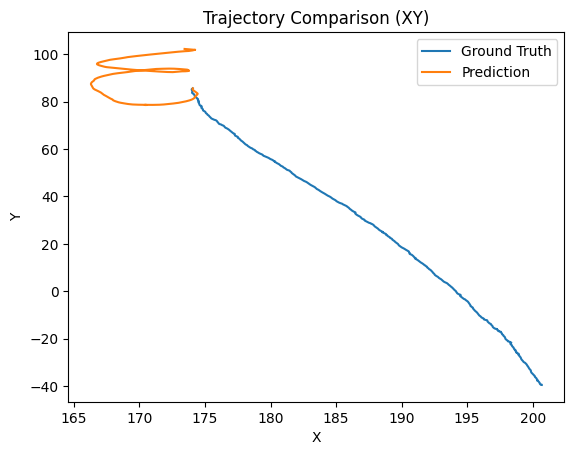

In [16]:
import matplotlib.pyplot as plt

plt.plot(gt_xyz[:,0], gt_xyz[:,1], label="Ground Truth")
plt.plot(pred_traj[:,0], pred_traj[:,1], label="Prediction")

plt.legend()
plt.title("Trajectory Comparison (XY)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

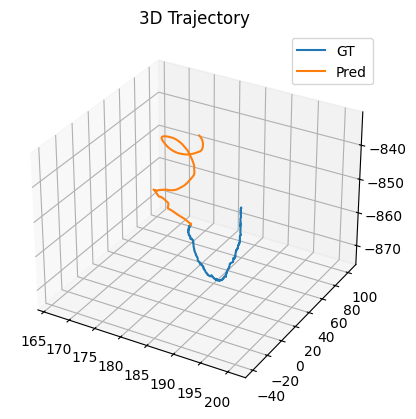

In [17]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(gt_xyz[:,0], gt_xyz[:,1], gt_xyz[:,2], label="GT")
ax.plot(pred_traj[:,0], pred_traj[:,1], pred_traj[:,2], label="Pred")

ax.legend()
plt.title("3D Trajectory")
plt.show()

In [18]:
import numpy as np

translation_error = np.linalg.norm(
    gt_xyz - pred_traj,
    axis=1
)

print("Mean Translation Error:", translation_error.mean())
print("RMSE:", np.sqrt(np.mean(translation_error**2)))

Mean Translation Error: 74.1522773173682
RMSE: 86.75773244558395


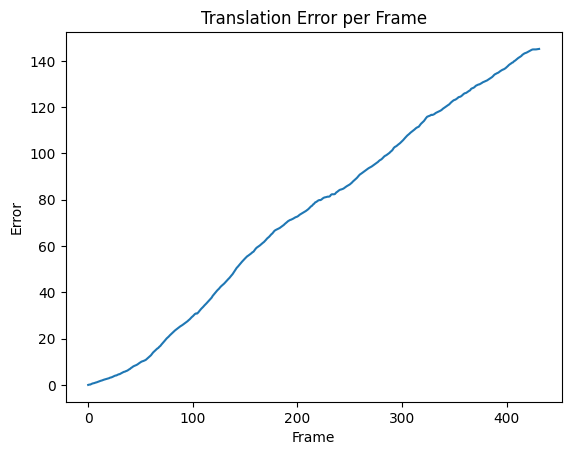

In [19]:
import matplotlib.pyplot as plt

plt.plot(translation_error)
plt.title("Translation Error per Frame")
plt.xlabel("Frame")
plt.ylabel("Error")
plt.show()